RISK ENGINEERING

In [183]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

fraud_data = pd.read_csv('C:\\Videos of Python and HTML\\Project\\Financial_Fraud_Risk_Monitoring_System\\Data\\fraud_data_cleaned.csv')

In [184]:
fraud_data.head()

,S.No,trans_date_trans_time,cc_num,merchant,category,amount,first_name,last_name,gender,street,...,unix_time,merch_lat,merch_long,is_fraud,transaction_date,transaction_hour,transaction_day,transaction_month,full_name,customer_age
0,0,2020-06-21 12:14:00,2.291160e+15,fraud_Kirlin and Sons,personal_care,2.86,Jeff,Elliott,M,351 Darlene Green,...,1371816865,33.986391,-81.200714,0,2020-06-21,12,Sunday,June,Jeff Elliott,58
1,1,2020-06-21 12:14:00,3.573030e+15,fraud_Sporer-Keebler,personal_care,29.84,Joanne,Williams,F,3638 Marsh Union,...,1371816873,39.450498,-109.960431,0,2020-06-21,12,Sunday,June,Joanne Williams,36
2,2,2020-06-21 12:14:00,3.598220e+15,"fraud_Swaniawski, Nitzsche and Welch",health_fitness,41.28,Ashley,Lopez,F,9333 Valentine Point,...,1371816893,40.495810,-74.196111,0,2020-06-21,12,Sunday,June,Ashley Lopez,55
3,3,2020-06-21 12:15:00,3.591920e+15,fraud_Haley Group,misc_pos,60.05,Brian,Williams,M,32941 Krystal Mill Apt. 552,...,1371816915,28.812398,-80.883061,0,2020-06-21,12,Sunday,June,Brian Williams,38
4,4,2020-06-21 12:15:00,3.526830e+15,fraud_Johnston-Casper,travel,3.19,Nathan,Massey,M,5783 Evan Roads Apt. 465,...,1371816917,44.959148,-85.884734,0,2020-06-21,12,Sunday,June,Nathan Massey,70


Creating Transaction Amount Risk Levels

In [186]:
fraud_data['risk_severity'] = pd.cut(fraud_data['amount'], bins=[0, 100, 500, 2000, fraud_data['amount'].max()], labels = ['Low', 'Medium', 'High', 'Critical'])
print(fraud_data['risk_severity'].value_counts())

risk_severity
Low         455734
Medium       93907
High          5719
Critical       359
Name: count, dtype: int64


Creating Fraud Score

In [187]:
fraud_data['fraud_score'] = 0


High Amount Transactions

In [188]:
fraud_data.loc[fraud_data['amount'] > 2000, 'fraud_score'] += 30

Night Transactions

In [189]:
fraud_data.loc[
    (fraud_data['transaction_hour'] >= 22) |
    (fraud_data['transaction_hour'] <= 4),
    'fraud_score'
] += 20

Fraudulent Categories

In [190]:
print(fraud_data['category'].value_counts())

category
gas_transport     56370
grocery_pos       52553
home              52345
shopping_pos      49791
kids_pets         48692
shopping_net      41779
entertainment     40104
personal_care     39327
food_dining       39268
health_fitness    36674
misc_pos          34574
misc_net          27367
grocery_net       19426
travel            17449
Name: count, dtype: int64


In [191]:
high_risk_categories = ['gas_transport', 'grocery_pos', 'home', 'shopping_pos', 'kids_pets']

In [192]:
fraud_data.loc[
    fraud_data['category'].isin(high_risk_categories),
    'fraud_score'
] += 25

Fraud Label

In [193]:
fraud_data.loc[fraud_data['is_fraud'] == 1, 'fraud_score'] += 40

Fraud Score Classification

In [197]:
fraud_data['fraud_risk_level'] = pd.cut(
    fraud_data['fraud_score'],
    bins=[-10, 20, 40, 60, 80, 100],
    labels=['No Risk','Low Risk', 'Medium Risk', 'High Risk', 'Critical Risk']
)

In [198]:
fraud_data.tail()
fraud_data.head()


,S.No,trans_date_trans_time,cc_num,merchant,category,amount,first_name,last_name,gender,street,...,is_fraud,transaction_date,transaction_hour,transaction_day,transaction_month,full_name,customer_age,risk_severity,fraud_score,fraud_risk_level
0,0,2020-06-21 12:14:00,2.291160e+15,fraud_Kirlin and Sons,personal_care,2.86,Jeff,Elliott,M,351 Darlene Green,...,0,2020-06-21,12,Sunday,June,Jeff Elliott,58,Low,0,No Risk
1,1,2020-06-21 12:14:00,3.573030e+15,fraud_Sporer-Keebler,personal_care,29.84,Joanne,Williams,F,3638 Marsh Union,...,0,2020-06-21,12,Sunday,June,Joanne Williams,36,Low,0,No Risk
2,2,2020-06-21 12:14:00,3.598220e+15,"fraud_Swaniawski, Nitzsche and Welch",health_fitness,41.28,Ashley,Lopez,F,9333 Valentine Point,...,0,2020-06-21,12,Sunday,June,Ashley Lopez,55,Low,0,No Risk
3,3,2020-06-21 12:15:00,3.591920e+15,fraud_Haley Group,misc_pos,60.05,Brian,Williams,M,32941 Krystal Mill Apt. 552,...,0,2020-06-21,12,Sunday,June,Brian Williams,38,Low,0,No Risk
4,4,2020-06-21 12:15:00,3.526830e+15,fraud_Johnston-Casper,travel,3.19,Nathan,Massey,M,5783 Evan Roads Apt. 465,...,0,2020-06-21,12,Sunday,June,Nathan Massey,70,Low,0,No Risk


Alert Flag System

In [199]:
fraud_data['alert_flag'] = np.where(
    fraud_data['fraud_score'] >= 40,
    'Generate Alert',
    'Normal'
)

Alert Distribution

In [200]:
print(fraud_data['alert_flag'].value_counts())

alert_flag
Normal            478753
Generate Alert     76966
Name: count, dtype: int64


Suspicious Transactions Indicators

High Value Suspicious Transaction

In [201]:
fraud_data['high_value_flag'] = np.where(
    fraud_data['amount'] > 1000,
    1,
    0
)

Night Transaction Flag

In [202]:
fraud_data['night_transaction_flag'] = np.where(
    (fraud_data['transaction_hour'] >= 23) |
    (fraud_data['transaction_hour'] <= 4),
    1,
    0
)

Repeated Fraud Customer Flag

In [203]:
fraud_counts = fraud_data.groupby('cc_num')['is_fraud'].sum()

high_risk_customers = fraud_counts[fraud_counts >= 3].index

In [204]:
fraud_data['repeat_fraud_customer_flag'] = np.where(
    fraud_data['cc_num'].isin(high_risk_customers),
    1,
    0
)

High-Risk Merchant Analysis

Merchant Fraud Rate

In [205]:
merchant_risk = fraud_data.groupby('merchant')['is_fraud'].mean().reset_index()

merchant_risk.columns = ['merchant', 'merchant_fraud_rate']

Merge Back

In [206]:
fraud_data = fraud_data.merge(
    merchant_risk,
    on='merchant',
    how='left'
)

Merchant Risk Classification

In [207]:
fraud_data['merchant_risk_level'] = pd.cut(
    fraud_data['merchant_fraud_rate'],
    bins=[-0.01, 0.01, 0.05, 0.1, 1],
    labels=['Low', 'Medium', 'High', 'Critical']
)

Compliance Threshold Monitoring

In [208]:
fraud_data['compliance_review_flag'] = np.where(
    fraud_data['amount'] >= 10000,
    'Review Required',
    'Normal'
)

Fraud Summary by State

In [209]:
state_risk_summary = fraud_data.groupby('state').agg({
    'is_fraud':'sum',
    'amount':'sum',
    'fraud_score':'mean'
}).reset_index()

Merchant Risk Summary

In [210]:
merchant_summary = fraud_data.groupby('merchant').agg({
    'is_fraud':'sum',
    'amount':'sum',
    'merchant_fraud_rate':'mean'
}).reset_index()

Visualizations

Fraud Score Distribution

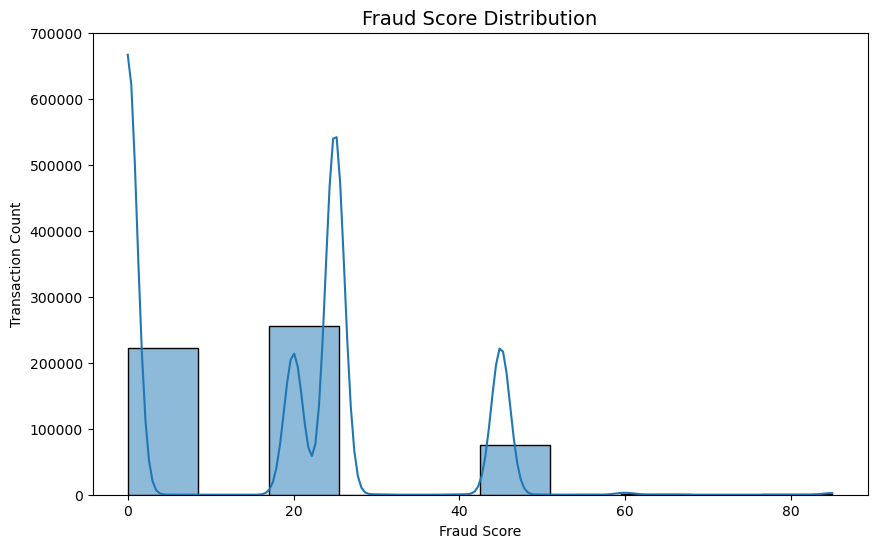

In [211]:
plt.figure(figsize=(10,6))
sns.histplot(fraud_data['fraud_score'], bins=10, kde=True)
plt.title("Fraud Score Distribution", fontsize=14)
plt.xlabel("Fraud Score")
plt.ylabel("Transaction Count")
plt.show()

Fraud risk level distribution

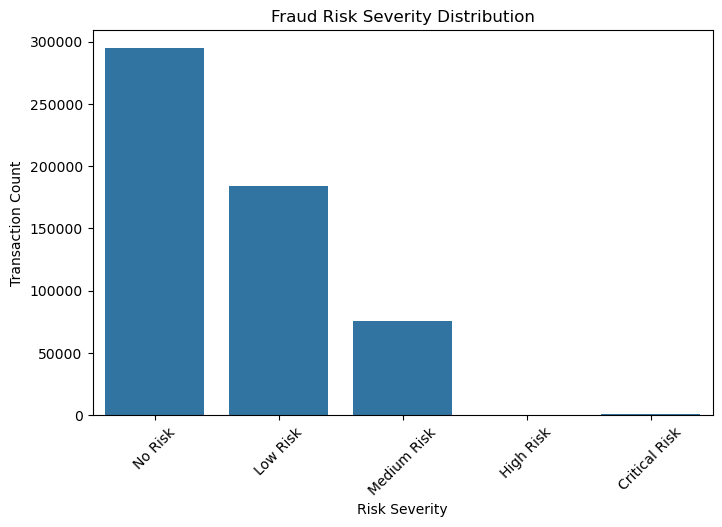

In [212]:
plt.figure(figsize=(8,5))
sns.countplot(x='fraud_risk_level', data=fraud_data)

plt.title('Fraud Risk Severity Distribution')
plt.xlabel("Risk Severity")
plt.ylabel("Transaction Count")
plt.xticks(rotation=45)
plt.show()

Alert Flag Analysis

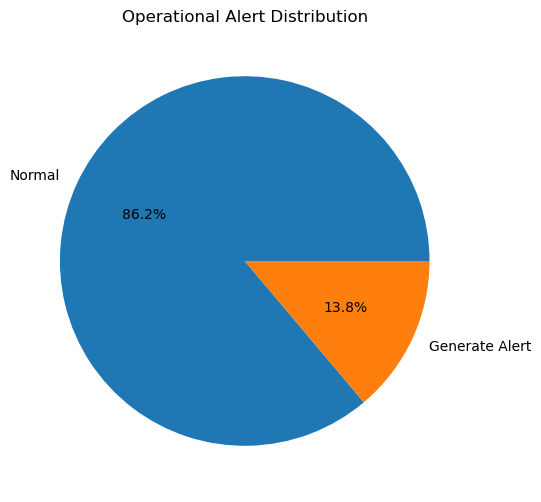

In [213]:
alert_counts = fraud_data['alert_flag'].value_counts()

plt.figure(figsize=(6,6))
plt.pie(
    alert_counts,
    labels=alert_counts.index,
    autopct='%1.1f%%'
)
plt.title("Operational Alert Distribution")
plt.show()

High-Value Transactions

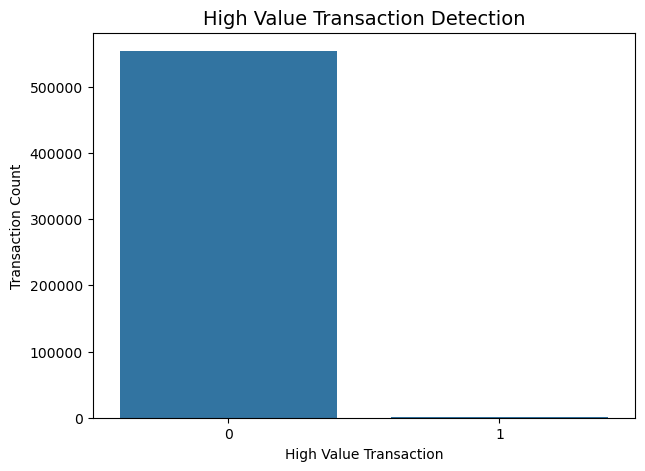

In [214]:
plt.figure(figsize=(7,5))

sns.countplot(x='high_value_flag', data=fraud_data)
plt.title("High Value Transaction Detection", fontsize=14)
plt.xlabel("High Value Transaction")
plt.ylabel("Transaction Count")
plt.show()

Top High-Risk Merchants

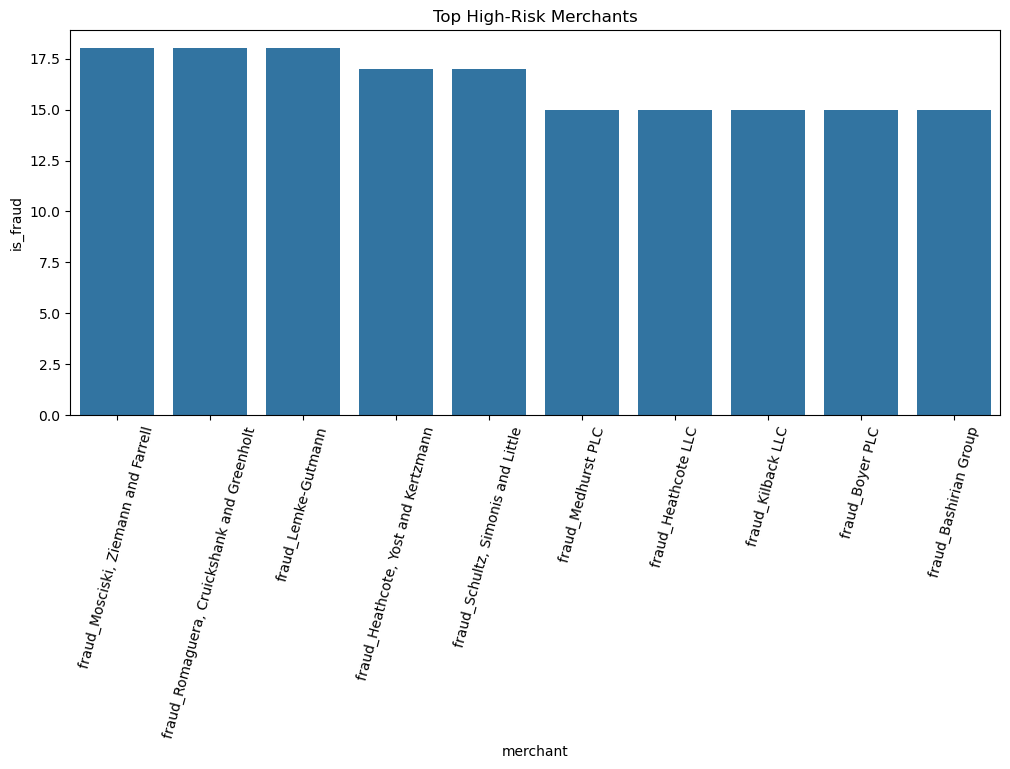

In [215]:
top_merchants = merchant_summary.sort_values(by='is_fraud', ascending=False).head(10)

plt.figure(figsize=(12,5))
sns.barplot(x='merchant', y='is_fraud', data=top_merchants)
plt.xticks(rotation=75)
plt.title('Top High-Risk Merchants')
plt.show()

In [216]:
fraud_data.head()

,S.No,trans_date_trans_time,cc_num,merchant,category,amount,first_name,last_name,gender,street,...,risk_severity,fraud_score,fraud_risk_level,alert_flag,high_value_flag,night_transaction_flag,repeat_fraud_customer_flag,merchant_fraud_rate,merchant_risk_level,compliance_review_flag
0,0,2020-06-21 12:14:00,2.291160e+15,fraud_Kirlin and Sons,personal_care,2.86,Jeff,Elliott,M,351 Darlene Green,...,Low,0,No Risk,Normal,0,0,0,0.004076,Low,Normal
1,1,2020-06-21 12:14:00,3.573030e+15,fraud_Sporer-Keebler,personal_care,29.84,Joanne,Williams,F,3638 Marsh Union,...,Low,0,No Risk,Normal,0,0,0,0.001274,Low,Normal
2,2,2020-06-21 12:14:00,3.598220e+15,"fraud_Swaniawski, Nitzsche and Welch",health_fitness,41.28,Ashley,Lopez,F,9333 Valentine Point,...,Low,0,No Risk,Normal,0,0,0,0.001325,Low,Normal
3,3,2020-06-21 12:15:00,3.591920e+15,fraud_Haley Group,misc_pos,60.05,Brian,Williams,M,32941 Krystal Mill Apt. 552,...,Low,0,No Risk,Normal,0,0,1,0.004219,Low,Normal
4,4,2020-06-21 12:15:00,3.526830e+15,fraud_Johnston-Casper,travel,3.19,Nathan,Massey,M,5783 Evan Roads Apt. 465,...,Low,0,No Risk,Normal,0,0,0,0.002703,Low,Normal


In [217]:
fraud_data.to_csv('C:\\Videos of Python and HTML\\Project\\Financial_Fraud_Risk_Monitoring_System\\Data\\risk_engineered_transactions.csv', index=False)